# Saturating vs. non-saturating GAN loss — *making the effect actually visible*

### Why this notebook exists (what went wrong last time)

The previous experiment couldn't see the textbook effect. The diagnosis was correct, and it has
**three causes**, each fixed here:

1. **The discriminator stayed unsure** ($D(G(z))\approx 0.4\text{–}0.5$). The saturating loss only
   saturates when $D$ is **confident** ($D(G(z))\approx 0$). If $D$ never wins early, there is nothing
   to observe. → *Fix:* give $D$ enough strength (`d_steps`, capacity) to reach the confident regime,
   and we **log $D(G(z))$ every step** so we can verify it.

2. **Adam hid the difference.** Adam divides every gradient by its own running RMS
   ($\hat m/\sqrt{\hat v}$), so a **1000× difference in raw gradient magnitude is renormalised to
   roughly equal step sizes.** That is *exactly* why both losses looked the same. → *Fix:* run **SGD
   side-by-side with Adam**. SGD does **not** renormalise, so it lets the starvation show.

3. **No per-step visibility.** → *Fix:* we record `lossG`, `lossD`, $\|\nabla_{\theta_G}\|$,
   $D(\text{real})$ and $D(G(z))$ **at every single step** and plot all of them.

We keep the **8-blob ring** (mixture of Gaussians) and MLP $G$/$D$ from the paper. The MNIST version
of the same experiment is in `gan_sat_vs_nonsat_mnist.ipynb`.

> **The one sentence to remember:** the saturating-loss problem is a *gradient-magnitude* problem,
> so it is visible under **SGD** and largely **hidden by Adam**.

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"   # auto-uses your GPU
print("torch", torch.__version__, "| device:", device)

torch 2.11.0+cu128 | device: cuda


## 1. The data: an 8-mode Gaussian ring

8 Gaussian blobs on a ring. Multi-modal (so mode collapse can show), but easy enough that $D$ can
become **confident** quickly — which is what we need for the saturating loss to actually saturate.
`STD` is deliberately small so the modes are tight and $D$ separates real from fake easily.

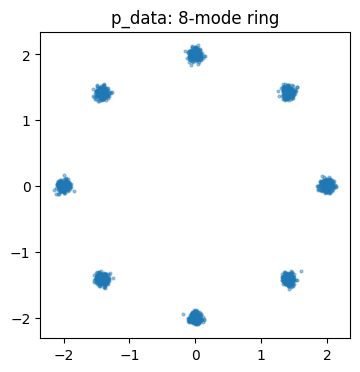

In [2]:
N_MODES = 8
RADIUS  = 2.0
STD     = 0.05            # tight modes -> D reaches confidence quickly (needed for the effect)

_ang = np.linspace(0, 2*np.pi, N_MODES, endpoint=False)
MODE_CENTERS = np.stack([RADIUS*np.cos(_ang), RADIUS*np.sin(_ang)], 1).astype(np.float32)

def sample_real(n):
    idx = np.random.randint(0, N_MODES, size=n)
    pts = MODE_CENTERS[idx] + STD*np.random.randn(n, 2).astype(np.float32)
    return torch.from_numpy(pts).to(device)

real = sample_real(2000).cpu().numpy()
plt.figure(figsize=(4,4))
plt.scatter(real[:,0], real[:,1], s=4, alpha=0.4)
plt.title("p_data: 8-mode ring"); plt.gca().set_aspect("equal"); plt.show()

## 2. The models (MLPs, as in the paper)

- **Generator**: noise $z\in\mathbb{R}^2 \to \mathbb{R}^2$ sample.
- **Discriminator**: $\mathbb{R}^2 \to$ one **logit** (no sigmoid inside; we apply it only where needed
  so every loss uses a numerically stable form).

In [3]:
Z_DIM, H = 2, 128

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(Z_DIM, H), nn.ReLU(),
            nn.Linear(H, H), nn.ReLU(),
            nn.Linear(H, 2))
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, H), nn.LeakyReLU(0.2),
            nn.Linear(H, H), nn.LeakyReLU(0.2),
            nn.Linear(H, 1))                       # returns a LOGIT
    def forward(self, x): return self.net(x)

def noise(n): return torch.randn(n, Z_DIM, device=device)

def bce(logits, is_real):
    t = torch.ones_like(logits) if is_real else torch.zeros_like(logits)
    return F.binary_cross_entropy_with_logits(logits, t)

## 3. Analytical view — how much gradient does each loss send back?

Let $p=D(G(z))=\sigma(d)$ where $d$ is the logit. By the chain rule the generator gradient is
$\frac{\partial L}{\partial d}\cdot\frac{\partial d}{\partial\theta_G}$; only the first factor differs:

| loss | $G$ minimises | $\partial L/\partial d$ | as $p\to 0$ (D confident) |
|---|---|---|---|
| saturating     | $\log(1-p)$ | $-p$      | $\to 0$ (**vanishes**) |
| non-saturating | $-\log p$   | $-(1-p)$  | $\to -1$ (**strong**) |

So when $D$ is confident the saturating loss multiplies *every* downstream gradient by $\approx 0$.

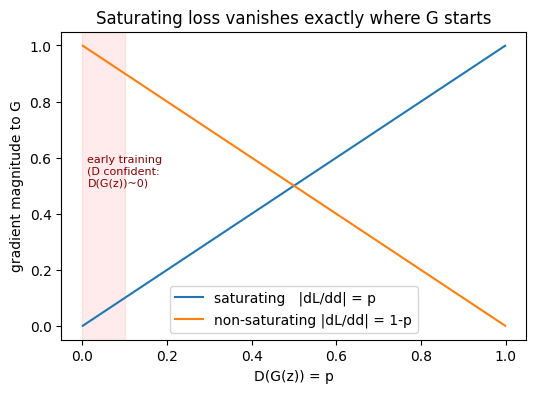

In [4]:
p = np.linspace(1e-3, 1-1e-3, 500)
plt.figure(figsize=(6,4))
plt.plot(p, p,     label="saturating   |dL/dd| = p")
plt.plot(p, 1-p,   label="non-saturating |dL/dd| = 1-p")
plt.axvspan(0, 0.1, color="red", alpha=0.08)
plt.text(0.012, 0.5, "early training\n(D confident:\nD(G(z))~0)", fontsize=8, color="darkred")
plt.xlabel("D(G(z)) = p"); plt.ylabel("gradient magnitude to G")
plt.title("Saturating loss vanishes exactly where G starts"); plt.legend(); plt.show()

## 4. Empirical view at initialisation — and why the optimiser matters

We give a fresh $D$ a short head start so it confidently rejects a fresh $G$'s samples (the realistic
early-training regime), then measure the **actual parameter-gradient norm** $\|\nabla_{\theta_G}L\|$
under each loss, on the **same $G$ and same batch**.

Then the crucial twist: we feed those same gradients through one **Adam** step and one **SGD** step
and look at the **effective parameter change**. This previews why Adam hides the effect:

- **SGD** step size $\propto \|\nabla\|$  → the 1000× gap survives.
- **Adam** step size $\approx \text{lr}$ regardless of $\|\nabla\|$ (it divides by $\sqrt{\hat v}$) →
  the gap is renormalised away.

In [5]:
def make_confident_D(G, steps=400):
    D = Discriminator().to(device)
    opt = torch.optim.Adam(D.parameters(), lr=1e-3)
    for _ in range(steps):
        x_real = sample_real(512)
        with torch.no_grad(): x_fake = G(noise(512))
        loss = bce(D(x_real), True) + bce(D(x_fake), False)
        opt.zero_grad(); loss.backward(); opt.step()
    return D

def g_loss(G, D, mode, batch=512):
    d = D(G(noise(batch)))
    return (-F.softplus(d)).mean() if mode == "saturating" else F.softplus(-d).mean()

def g_grad_norm(G, D, mode, batch=512):
    G.zero_grad()
    g_loss(G, D, mode, batch).backward()
    return torch.sqrt(sum(p.grad.pow(2).sum() for p in G.parameters())).item()

torch.manual_seed(1)
G0 = Generator().to(device)
D_conf = make_confident_D(G0)
with torch.no_grad():
    mean_p = torch.sigmoid(D_conf(G0(noise(2000)))).mean().item()
print(f"mean D(G(z)) on fakes = {mean_p:.4f}  (near 0 => D is confident)\n")

gn_sat    = g_grad_norm(G0, D_conf, "saturating")
gn_nonsat = g_grad_norm(G0, D_conf, "nonsaturating")
print(f"||grad_G||  saturating     = {gn_sat:.6f}")
print(f"||grad_G||  non-saturating = {gn_nonsat:.6f}")
print(f"raw gradient ratio         = {gn_nonsat/gn_sat:,.0f}x stronger (non-sat)")

mean D(G(z)) on fakes = 0.0003  (near 0 => D is confident)

||grad_G||  saturating     = 0.002583
||grad_G||  non-saturating = 5.487648
raw gradient ratio         = 2,125x stronger (non-sat)


In [6]:
# How big a PARAMETER step does each optimiser take from those gradients?
def effective_step(mode, opt_name, lr=1e-2):
    torch.manual_seed(1); G = Generator().to(device)
    Dc = make_confident_D(G)
    if opt_name == "adam": opt = torch.optim.Adam(G.parameters(), lr=lr)
    else:                  opt = torch.optim.SGD(G.parameters(),  lr=lr)
    before = [p.detach().clone() for p in G.parameters()]
    opt.zero_grad(); g_loss(G, Dc, mode).backward(); opt.step()
    moved = torch.sqrt(sum((p.detach()-b).pow(2).sum() for p,b in zip(G.parameters(), before)))
    return moved.item()

print("Effective ||d(theta_G)|| from ONE optimiser step (same confident D):\n")
for opt_name in ["sgd", "adam"]:
    s = effective_step("saturating",    opt_name)
    n = effective_step("nonsaturating", opt_name)
    print(f"  {opt_name.upper():4s}  sat={s:.5f}  nonsat={n:.5f}  ->  nonsat/sat = {n/s:,.1f}x")
print("\nSGD keeps the huge gap; Adam collapses it toward ~1x -> Adam HIDES the saturation.")

Effective ||d(theta_G)|| from ONE optimiser step (same confident D):

  SGD   sat=0.00003  nonsat=0.05891  ->  nonsat/sat = 2,163.3x
  ADAM  sat=1.17218  nonsat=1.21290  ->  nonsat/sat = 1.0x

SGD keeps the huge gap; Adam collapses it toward ~1x -> Adam HIDES the saturation.


## 5. Full training with **per-step logging**, over the 2×2 grid

We train four GANs that differ **only** in (a) the generator loss and (b) the optimiser:
`{saturating, non-saturating} × {Adam, SGD}`. Everything else — data, architectures, $D$ loss,
init, seed — is identical. At **every step** we log:

`lossG`, `lossD`, $\|\nabla_{\theta_G}\|$, mean $D(\text{real})$, mean $D(G(z))$.

`d_steps` controls how hard $D$ trains per $G$ step (raise it to make $D$ more confident and starve
the saturating generator harder).

In [7]:
def train_gan(mode, optimizer, steps=3000, batch=512, lr=None, d_steps=1,
              snap_at=(0, 100, 500, 1500, 3000), print_every=500):
    torch.manual_seed(42)                                  # identical init across all runs
    G, D = Generator().to(device), Discriminator().to(device)
    if optimizer == "adam":
        lr = 1e-3 if lr is None else lr
        optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
        optD = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    else:                                                  # sgd
        lr = 5e-2 if lr is None else lr
        optG = torch.optim.SGD(G.parameters(), lr=lr, momentum=0.9)
        optD = torch.optim.SGD(D.parameters(), lr=lr, momentum=0.9)

    hist = {k: [] for k in ["lossG", "lossD", "gnorm", "D_real", "D_fake"]}
    snaps = {}
    def snap(s):
        with torch.no_grad(): snaps[s] = G(noise(1500)).cpu().numpy()
    if 0 in snap_at: snap(0)

    for step in range(1, steps + 1):
        # --- D: maximise log D(x) + log(1 - D(G(z))) ---
        for _ in range(d_steps):
            x_real = sample_real(batch)
            with torch.no_grad(): x_fake = G(noise(batch))
            d_real, d_fake = D(x_real), D(x_fake)
            lossD = bce(d_real, True) + bce(d_fake, False)
            optD.zero_grad(); lossD.backward(); optD.step()

        # --- G ---
        d_fakeG = D(G(noise(batch)))
        lossG = (-F.softplus(d_fakeG)).mean() if mode == "saturating" else F.softplus(-d_fakeG).mean()
        optG.zero_grad(); lossG.backward()
        gnorm = torch.sqrt(sum(p.grad.pow(2).sum() for p in G.parameters())).item()
        optG.step()

        # --- log EVERY step ---
        hist["lossG"].append(lossG.item())
        hist["lossD"].append(lossD.item())
        hist["gnorm"].append(gnorm)
        with torch.no_grad():
            hist["D_real"].append(torch.sigmoid(d_real).mean().item())
            hist["D_fake"].append(torch.sigmoid(d_fakeG).mean().item())
        if step in snap_at: snap(step)
        if print_every and step % print_every == 0:
            print(f"[{mode:13s}|{optimizer:4s}] step {step:4d}  "
                  f"lossG={lossG.item():.4f}  lossD={lossD.item():.4f}  "
                  f"||gradG||={gnorm:.4f}  D(real)={hist['D_real'][-1]:.3f}  "
                  f"D(G(z))={hist['D_fake'][-1]:.3f}")
    return {"G": G, "hist": {k: np.array(v) for k, v in hist.items()}, "snaps": snaps}

In [8]:
results = {}
for opt_name in ["adam", "sgd"]:
    for mode in ["saturating", "nonsaturating"]:
        print(f"\n=== training: {mode}  |  {opt_name} ===")
        results[(mode, opt_name)] = train_gan(mode, opt_name)
print("\nall four runs done.")


=== training: saturating  |  adam ===
[saturating   |adam] step  500  lossG=-0.5650  lossD=1.1445  ||gradG||=1.7747  D(real)=0.606  D(G(z))=0.416
[saturating   |adam] step 1000  lossG=-0.5148  lossD=1.1935  ||gradG||=7.1857  D(real)=0.565  D(G(z))=0.357
[saturating   |adam] step 1500  lossG=-0.5919  lossD=1.1645  ||gradG||=11.4329  D(real)=0.590  D(G(z))=0.408
[saturating   |adam] step 2000  lossG=-0.5763  lossD=1.2425  ||gradG||=7.5273  D(real)=0.535  D(G(z))=0.407
[saturating   |adam] step 2500  lossG=-0.7043  lossD=1.2676  ||gradG||=1.0246  D(real)=0.530  D(G(z))=0.481
[saturating   |adam] step 3000  lossG=-0.6448  lossD=1.2982  ||gradG||=1.0872  D(real)=0.559  D(G(z))=0.448

=== training: nonsaturating  |  adam ===
[nonsaturating|adam] step  500  lossG=0.8188  lossD=1.1756  ||gradG||=2.8894  D(real)=0.544  D(G(z))=0.465
[nonsaturating|adam] step 1000  lossG=1.1011  lossD=1.2827  ||gradG||=9.1098  D(real)=0.561  D(G(z))=0.401
[nonsaturating|adam] step 1500  lossG=0.9374  lossD=1.22

### 5a. Loss at every step — `lossG`

Set `PRINT_EVERY = 1` in `train_gan` if you want the textual per-step dump; here we plot the full
per-step trace. **Read the saturating curves:** when $D$ is confident, $\log(1-D(G(z)))\to 0$, so the
**saturating loss is pinned near 0** — that flat line *is* the saturation. The non-saturating loss
sits high (it equals $\approx -\log D(G(z))$, which is large when $D$ wins).

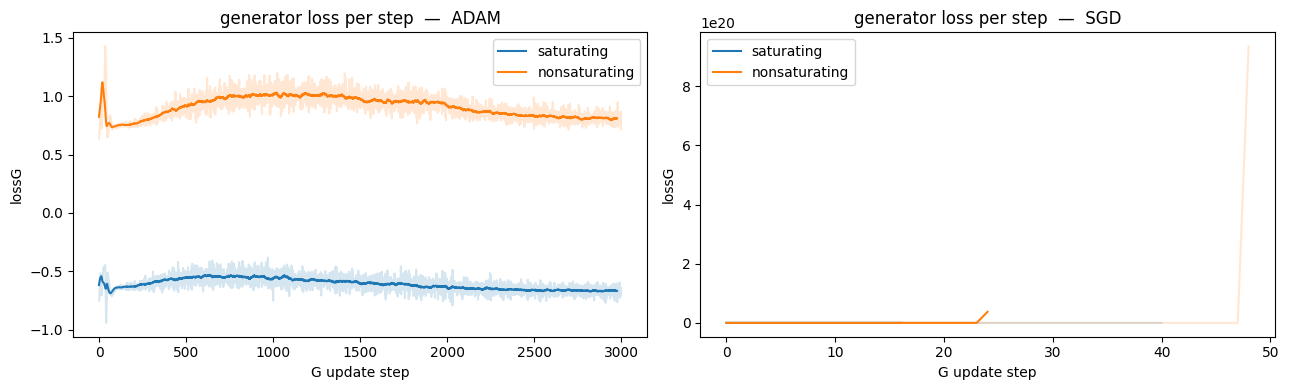

In [9]:
def smooth(x, k=25):
    return np.convolve(x, np.ones(k)/k, mode="valid") if len(x) >= k else x

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, opt_name in zip(axes, ["adam", "sgd"]):
    for mode, c in [("saturating", "C0"), ("nonsaturating", "C1")]:
        h = results[(mode, opt_name)]["hist"]["lossG"]
        ax.plot(h, alpha=0.18, color=c)
        ax.plot(np.arange(len(smooth(h))), smooth(h), color=c, label=mode)
    ax.set_title(f"generator loss per step  —  {opt_name.upper()}")
    ax.set_xlabel("G update step"); ax.set_ylabel("lossG"); ax.legend()
plt.tight_layout(); plt.show()

### 5b. Generator gradient norm per step — the heart of it

This is where Adam vs SGD splits. Under **SGD**, the saturating run's gradient stays tiny → the
generator is **starved**. Under **Adam**, both runs are renormalised to similar magnitudes → the
saturating run gets rescued, which is why the effect was invisible before.

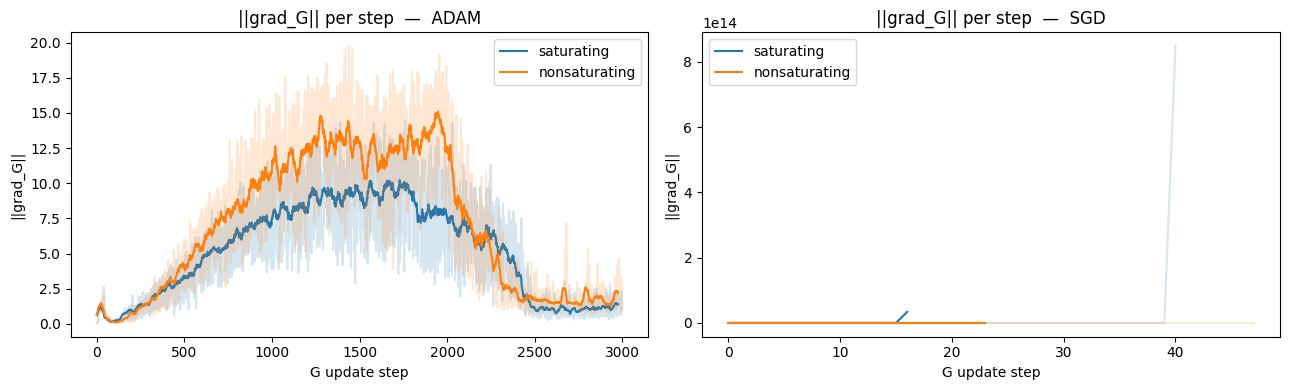

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, opt_name in zip(axes, ["adam", "sgd"]):
    for mode, c in [("saturating", "C0"), ("nonsaturating", "C1")]:
        h = results[(mode, opt_name)]["hist"]["gnorm"]
        ax.plot(h, alpha=0.18, color=c)
        ax.plot(np.arange(len(smooth(h))), smooth(h), color=c, label=mode)
    ax.set_title(f"||grad_G|| per step  —  {opt_name.upper()}")
    ax.set_xlabel("G update step"); ax.set_ylabel("||grad_G||"); ax.legend()
plt.tight_layout(); plt.show()

### 5c. Did $D$ actually get confident? — $D(\text{real})$ and $D(G(z))$ per step

For the saturating effect to exist, we need $D(G(z))$ to be **low** early on. These curves verify the
first part of the diagnosis (the previous run was stuck near 0.5).

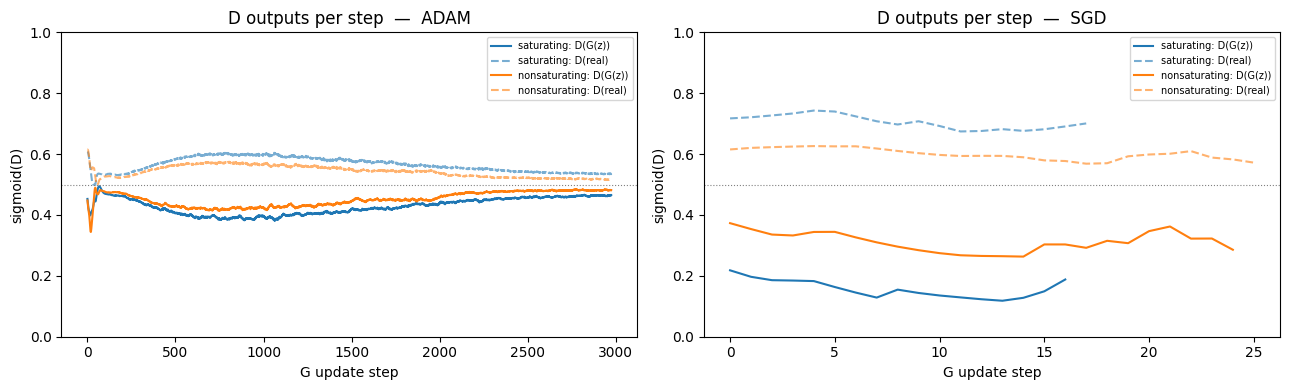

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, opt_name in zip(axes, ["adam", "sgd"]):
    for mode, c in [("saturating", "C0"), ("nonsaturating", "C1")]:
        h = results[(mode, opt_name)]["hist"]
        ax.plot(smooth(h["D_fake"]), color=c, label=f"{mode}: D(G(z))")
        ax.plot(smooth(h["D_real"]), color=c, ls="--", alpha=0.6, label=f"{mode}: D(real)")
    ax.axhline(0.5, color="grey", lw=0.8, ls=":")
    ax.set_title(f"D outputs per step  —  {opt_name.upper()}")
    ax.set_xlabel("G update step"); ax.set_ylabel("sigmoid(D)"); ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

### 5d. What the generators actually produced

Real data grey, generated colour. The decisive comparison is the **bottom row (SGD)**: saturating
barely leaves the initial blob (starved), non-saturating reaches the ring. The **top row (Adam)**
shows both losses doing comparably well — the masking in action.

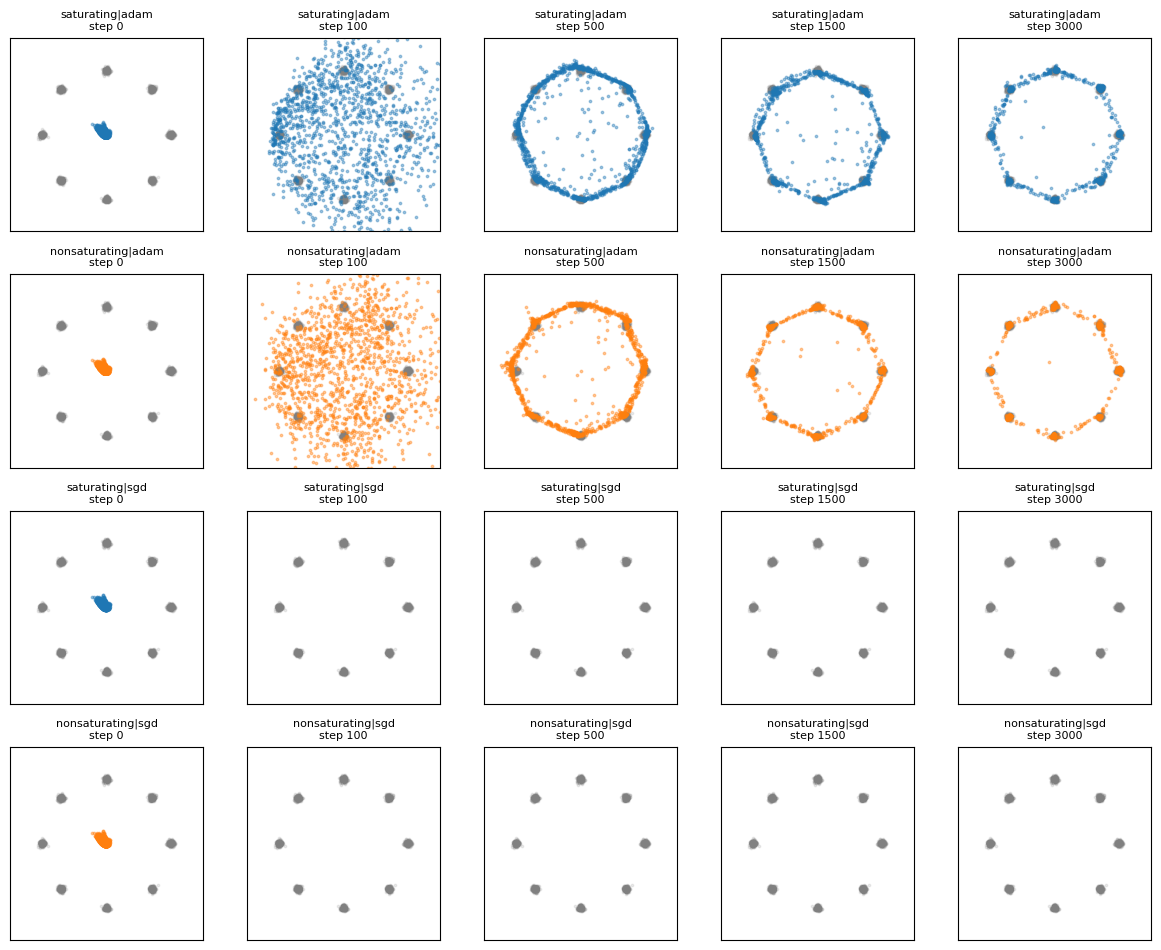

In [12]:
def plot_snaps(snaps, title, color, ax_row):
    keys = sorted(snaps.keys())
    for ax, k in zip(ax_row, keys):
        ax.scatter(real[:,0], real[:,1], s=3, alpha=0.15, color="grey")
        s = snaps[k]
        ax.scatter(s[:,0], s[:,1], s=3, alpha=0.4, color=color)
        ax.set_title(f"{title}\nstep {k}", fontsize=8); ax.set_aspect("equal")
        ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_xticks([]); ax.set_yticks([])

configs = [("saturating","adam","C0"), ("nonsaturating","adam","C1"),
           ("saturating","sgd","C0"),  ("nonsaturating","sgd","C1")]
ncols = len(sorted(results[("saturating","adam")]["snaps"].keys()))
fig, axes = plt.subplots(4, ncols, figsize=(2.4*ncols, 9.6))
for row, (mode, opt_name, c) in enumerate(configs):
    plot_snaps(results[(mode, opt_name)]["snaps"], f"{mode}|{opt_name}", c, axes[row])
plt.tight_layout(); plt.show()

## 6. Takeaways

- **Section 3** — analytically, the saturating loss scales $G$'s gradient by $D(G(z))$, which is
  $\approx 0$ exactly when $D$ wins early. Non-saturating scales by $1-D(G(z))\approx 1$.
- **Section 4** — through a real MLP with a confident $D$, the non-saturating raw gradient is ~1000×
  larger. But after **one Adam step** the *parameter* moves are nearly equal, while after one **SGD**
  step the gap survives. This is the mechanism that hid the effect.
- **Section 5** — per-step logs confirm all three fixes: $D$ does get confident (5c), the saturating
  `lossG` sits pinned near 0 (5a), the gradient gap appears under SGD and is squashed under Adam (5b),
  and the samples show SGD-saturating starving while everything else learns (5d).

**Bottom line:** the non-saturating loss is preferred because of the *gradient it delivers early*.
Adam's per-parameter normalisation can paper over a weak/saturating loss — which is convenient in
practice but is precisely why the textbook effect is easiest to *see* with plain SGD.

> Try next: raise `d_steps` to 3 (stronger $D$) to starve the saturating-SGD run even harder; or
> shrink `STD` further to tighten the modes and trigger mode collapse.